In [23]:
from keras.datasets import mnist

In [26]:
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from keras.models import Sequential

In [27]:
import matplotlib.pyplot as plt

In [28]:
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()

In [29]:
train_images.shape

(60000, 28, 28)

In [30]:
test_images.shape

(10000, 28, 28)

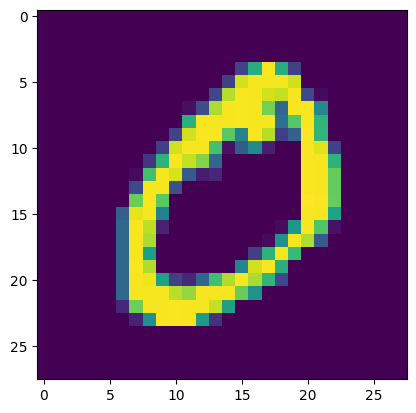

In [31]:
plt.imshow(train_images[1])

In [32]:
train_labels[1]

np.uint8(0)

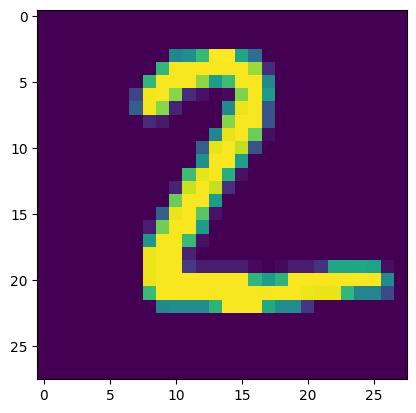

In [33]:
plt.imshow(test_images[1])

In [34]:
test_labels[1]

np.uint8(2)

In [35]:
train_images,test_images=train_images/255.0,test_images/255.0

In [36]:
import numpy as np
train_images=train_images.reshape(60000,28,28,1)
test_images=test_images.reshape(10000,28,28,1)

In [37]:
from keras.utils import to_categorical

In [38]:
train_labels=to_categorical(train_labels)

In [39]:
test_labels=to_categorical(test_labels)

In [40]:
test_labels[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [41]:
train_labels[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [42]:
cnnmodel=Sequential()

In [43]:
cnnmodel.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
cnnmodel.add(MaxPooling2D(2,2))
cnnmodel.add(Conv2D(64,(3,3),activation='relu'))
cnnmodel.add(Flatten())
cnnmodel.add(Dense(10,activation='softmax'))

In [44]:
cnnmodel.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [45]:
cnnmodel.fit(train_images,train_labels,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9605 - loss: 0.1343
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9864 - loss: 0.0447
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9906 - loss: 0.0309


In [46]:
predictions=cnnmodel.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [47]:
for i in range(3):
    print(predictions[i])
    print(test_labels[i])

[1.8143362e-10 2.9068330e-09 2.1008157e-07 1.1171898e-06 1.0824721e-11
 1.8553825e-10 2.1170448e-16 9.9999869e-01 6.1540911e-10 3.6379500e-08]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[7.0841573e-09 1.6415630e-06 9.9996257e-01 1.9435864e-10 7.1634601e-11
 3.7622277e-11 3.5509656e-05 1.9725818e-11 2.3235026e-07 9.0565326e-11]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[3.0438819e-08 9.9995363e-01 1.6959082e-06 6.1261929e-08 1.2217726e-05
 1.1521748e-06 3.8150368e-08 1.7170161e-05 1.3944143e-05 6.5268821e-09]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
